In [1]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 20.5 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 11.9 MB/s  0:00:23m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [8]:

CSV_PATH = 'pet_dataset_600rows.csv'   # change if needed
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_JOBS = -1

In [9]:
# FEATURES and TARGETS as requested
FEATURES = ['Cement','Water','FineAggregate','CoarseAggregate','PET_%','w/c ratio']
TARGETS  = ['CS_7d','CS_28d']

In [21]:
# ---------------------------
# helper metrics (robust)
# ---------------------------
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    """
    Robust RMSE implementation that avoids the 'squared' kwarg.
    Accepts pandas Series/ndarray and returns scalar RMSE.
    """
    yt = np.array(y_true).ravel()
    yp = np.array(y_pred).ravel()
    return float(np.sqrt(mean_squared_error(yt, yp)))   # mean_squared_error returns MSE; take sqrt

def evaluate_multioutput(y_true, y_pred, targets=TARGETS):
    """
    y_true: pandas DataFrame (n_samples, n_targets)
    y_pred: numpy ndarray (n_samples, n_targets) OR pandas DataFrame/Series
    targets: list of target names (length == n_targets)
    Returns dict with per-target metrics + averages.
    """
    # convert to numpy arrays and ensure shape (n_samples, n_targets)
    y_pred_arr = np.array(y_pred)
    y_true_arr = np.array(y_true)

    if y_pred_arr.ndim == 1:
        y_pred_arr = y_pred_arr.reshape(-1, 1)
    if y_true_arr.ndim == 1:
        y_true_arr = y_true_arr.reshape(-1, 1)

    n_targets = y_true_arr.shape[1]
    # If length of 'targets' mismatches, trim/extend safely
    if len(targets) != n_targets:
        # try to use column count to create generic names if needed
        targets = [f"target_{i}" for i in range(n_targets)]

    results = {}
    for i, t in enumerate(targets):
        yt_col = y_true_arr[:, i]
        yp_col = y_pred_arr[:, i]
        results[t] = {
            'R2': float(r2_score(yt_col, yp_col)),
            'RMSE': float(rmse(yt_col, yp_col)),
            'MAE': float(mean_absolute_error(yt_col, yp_col))
        }

    results['avg_R2'] = float(np.mean([results[t]['R2'] for t in targets]))
    results['avg_RMSE'] = float(np.mean([results[t]['RMSE'] for t in targets]))
    results['avg_MAE'] = float(np.mean([results[t]['MAE'] for t in targets]))
    return results


In [12]:
# Load data & quick checks
# ---------------------------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
print("Loaded dataframe shape:", df.shape)
print("Dtypes:\n", df.dtypes)
print("\nPreview:")
print(df.head()[FEATURES + TARGETS])


Loaded dataframe shape: (600, 8)
Dtypes:
 Cement             float64
Water              float64
FineAggregate      float64
CoarseAggregate    float64
PET_%              float64
w/c ratio          float64
CS_7d              float64
CS_28d             float64
dtype: object

Preview:
   Cement  Water  FineAggregate  CoarseAggregate  PET_%  w/c ratio  CS_7d  \
0   400.0  192.0          610.0            841.0    0.0       0.48  28.98   
1   400.0  192.0          549.0            841.0   10.0       0.48  21.00   
2   400.0  192.0          522.0            841.0   20.0       0.48  20.46   
3   400.0  192.0          427.0            841.0   30.0       0.48  17.40   
4   400.0  192.0          366.0            841.0   40.0       0.48  10.40   

   CS_28d  
0   40.80  
1   28.88  
2   25.70  
3   18.34  
4   16.39  


In [22]:
# Basic NaN check
print("\nMissing values per column:")
print(df[FEATURES + TARGETS].isna().sum())


Missing values per column:
Cement             0
Water              0
FineAggregate      0
CoarseAggregate    0
PET_%              0
w/c ratio          0
CS_7d              0
CS_28d             0
dtype: int64


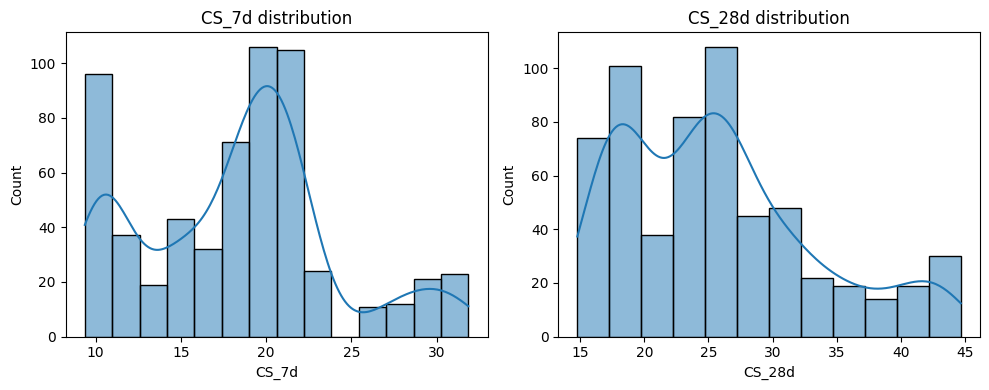

In [23]:
# 2) Quick EDA (distributions & correlations)
# ---------------------------
# distribution of targets
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df[TARGETS[0]], kde=True)
plt.title(TARGETS[0] + " distribution")

plt.subplot(1,2,2)
sns.histplot(df[TARGETS[1]], kde=True)
plt.title(TARGETS[1] + " distribution")
plt.tight_layout()
plt.show()


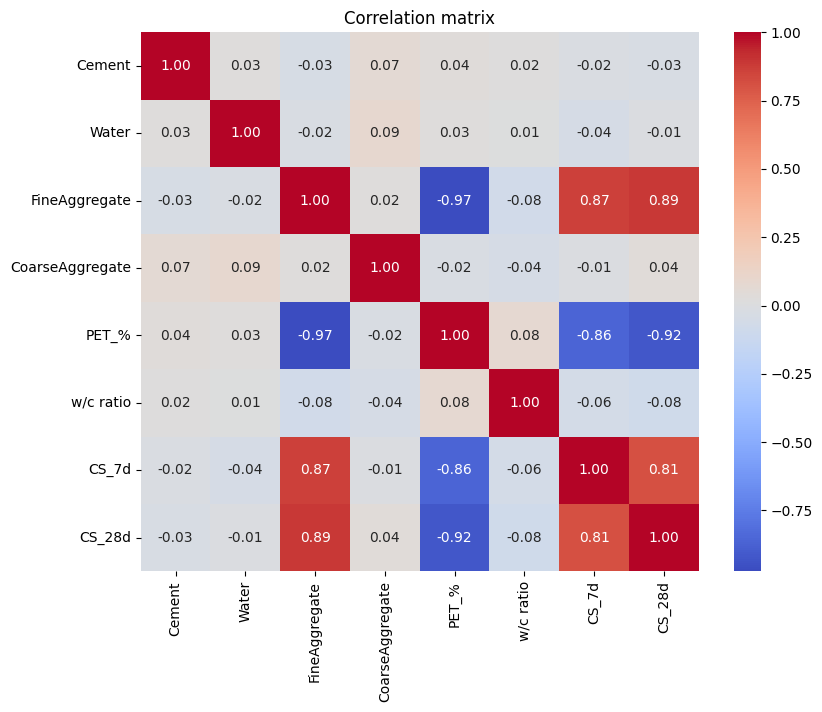

In [24]:
# correlation heatmap
plt.figure(figsize=(9,7))
sns.heatmap(df[FEATURES + TARGETS].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

In [25]:
# 3) Define features and targets
# ---------------------------
X = df[FEATURES].copy()
y = df[TARGETS].copy()

In [26]:
# 4) Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"\nTrain shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes:  X={X_test.shape}, y={y_test.shape}")



Train shapes: X=(480, 6), y=(480, 2)
Test shapes:  X=(120, 6), y=(120, 2)


In [27]:
# 5) Preprocessing pipeline
# ---------------------------
# We'll create two pipelines:
# - pipe_lr: scaler + linear regression (needs scaling)
# - For tree models we won't include scaler (but we could wrap scaler harmlessly)
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])


In [28]:
# 6) Baseline models
# ---------------------------
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate_multioutput(y_test, y_pred, TARGETS)
    print(f"\n{name} evaluation:")
    print_metrics(metrics)
    return metrics, model

In [29]:
# 6.1 Linear Regression (multi-output via MultiOutputRegressor)
print("\nTraining baseline Linear Regression (multi-output wrapper)...")
lr_multi = MultiOutputRegressor(pipe_lr, n_jobs=N_JOBS)
lr_metrics, lr_model = evaluate_model(lr_multi, "LinearRegression (multi-output)")



Training baseline Linear Regression (multi-output wrapper)...

LinearRegression (multi-output) evaluation:

--- Evaluation metrics ---

Target: CS_7d
  R2: 0.7348
  RMSE: 2.6615
  MAE: 2.1795

Target: CS_28d
  R2: 0.8304
  RMSE: 2.8677
  MAE: 2.3553
avg_R2: 0.7826
avg_RMSE: 2.7646
avg_MAE: 2.2674


In [30]:

# 6.2 Random Forest baseline (supports multi-output natively)
print("\nTraining baseline RandomForestRegressor...")
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=N_JOBS)
rf_metrics, rf_model = evaluate_model(rf, "RandomForest (baseline)")



Training baseline RandomForestRegressor...

RandomForest (baseline) evaluation:

--- Evaluation metrics ---

Target: CS_7d
  R2: 0.8184
  RMSE: 2.2022
  MAE: 1.6765

Target: CS_28d
  R2: 0.8636
  RMSE: 2.5725
  MAE: 2.0107
avg_R2: 0.8410
avg_RMSE: 2.3873
avg_MAE: 1.8436


In [31]:

# 6.3 XGBoost multi-output (wrapped)
print("\nTraining baseline XGBoost (wrapped in MultiOutputRegressor)...")
xgb_base = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                       random_state=RANDOM_STATE, verbosity=0, n_jobs=N_JOBS)
xgb_multi = MultiOutputRegressor(xgb_base, n_jobs=N_JOBS)
xgb_metrics, xgb_model = evaluate_model(xgb_multi, "XGBoost (multi-output)")



Training baseline XGBoost (wrapped in MultiOutputRegressor)...

XGBoost (multi-output) evaluation:

--- Evaluation metrics ---

Target: CS_7d
  R2: 0.7954
  RMSE: 2.3380
  MAE: 1.7079

Target: CS_28d
  R2: 0.8302
  RMSE: 2.8701
  MAE: 2.1887
avg_R2: 0.8128
avg_RMSE: 2.6041
avg_MAE: 1.9483


In [32]:

# 7) Cross-validation (reliability check) for RF (R2 average)
# ---------------------------
print("\nCross-validation (RF, 5-fold) - R2 scores (averaged multioutput via sklearn's cross_val_score)")
# cross_val_score with multioutput returns array for multioutput? sklearn accepts multioutput and returns score per split aggregated.
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=N_JOBS)
print("RF CV R2 mean:", cv_scores.mean(), "std:", cv_scores.std())



Cross-validation (RF, 5-fold) - R2 scores (averaged multioutput via sklearn's cross_val_score)
RF CV R2 mean: 0.8623870907277315 std: 0.007966267031389116


In [33]:

# 8) Hyperparameter tuning (RandomForest example)
# ---------------------------
print("\nHyperparameter tuning RandomizedSearchCV (RandomForest)...")
param_dist = {
    'n_estimators': [100, 200, 400],
    'max_depth': [6, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rsearch = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1
)
rsearch.fit(X_train, y_train)
print("Best RF params:", rsearch.best_params_)
best_rf = rsearch.best_estimator_



Hyperparameter tuning RandomizedSearchCV (RandomForest)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 6}


In [34]:

# Evaluate tuned RF
y_pred_best_rf = best_rf.predict(X_test)
best_rf_metrics = evaluate_multioutput(y_test, y_pred_best_rf, TARGETS)
print("\nRandomForest (tuned) metrics:")
print_metrics(best_rf_metrics)



RandomForest (tuned) metrics:

--- Evaluation metrics ---

Target: CS_7d
  R2: 0.8320
  RMSE: 2.1183
  MAE: 1.6578

Target: CS_28d
  R2: 0.8747
  RMSE: 2.4650
  MAE: 1.9758
avg_R2: 0.8534
avg_RMSE: 2.2916
avg_MAE: 1.8168



Feature importances (tuned RF):
 PET_%              0.654611
FineAggregate      0.299336
Cement             0.011811
Water              0.011599
w/c ratio          0.011443
CoarseAggregate    0.011201
dtype: float64


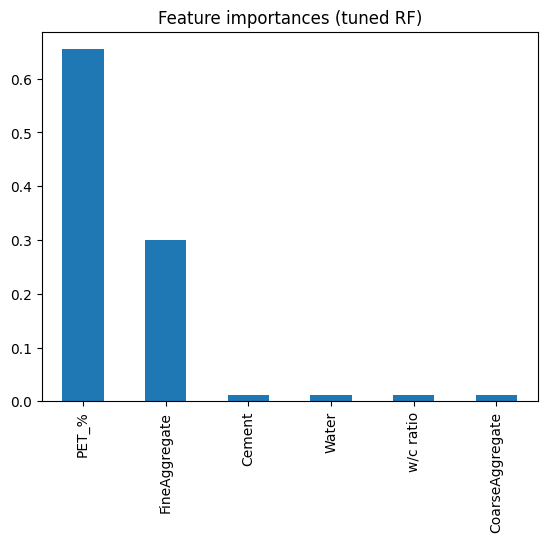

In [35]:

# 9) Feature importance (tuned RF)
# ---------------------------
try:
    fi = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
    print("\nFeature importances (tuned RF):\n", fi)
    fi.plot.bar()
    plt.title('Feature importances (tuned RF)')
    plt.show()
except Exception as e:
    print("Could not compute feature importances:", e)


In [41]:
# 10) Save the trained model(s)
OUTDIR = '.'   # save in the same folder as your CSV + script
# os.makedirs(OUTDIR, exist_ok=True)   # NOT NEEDED — current directory always exists

joblib.dump(best_rf, 'best_rf_multioutput_pet.joblib')
joblib.dump(xgb_multi, 'xgb_multi_pet.joblib')
joblib.dump(lr_model, 'lr_multi_pet.joblib')

print("\nSaved models to current directory.")



Saved models to current directory.


In [42]:
# 11) Inference / single prediction example
# ---------------------------
sample = X_test.iloc[0:3]
preds = best_rf.predict(sample)
print("\nSample predictions (tuned RF):")
for i in range(len(sample)):
    inp = sample.iloc[i].to_dict()
    print(f"Input {i}: {inp}")
    print(f" Predicted {TARGETS[0]}={preds[i,0]:.3f}, {TARGETS[1]}={preds[i,1]:.3f}")
    print(f" True      {TARGETS[0]}={y_test.iloc[i,0]:.3f}, {TARGETS[1]}={y_test.iloc[i,1]:.3f}\n")



Sample predictions (tuned RF):
Input 0: {'Cement': 392.5497732466396, 'Water': 190.97287290560368, 'FineAggregate': 533.8918146311821, 'CoarseAggregate': 826.996697093951, 'PET_%': 21.0, 'w/c ratio': 0.4408955177085493}
 Predicted CS_7d=20.688, CS_28d=24.906
 True      CS_7d=21.573, CS_28d=23.193

Input 1: {'Cement': 395.6660952484986, 'Water': 194.86769503357127, 'FineAggregate': 544.8979262759636, 'CoarseAggregate': 841.544441861773, 'PET_%': 11.0, 'w/c ratio': 0.4737917393354025}
 Predicted CS_7d=20.526, CS_28d=30.267
 True      CS_7d=20.166, CS_28d=30.188

Input 2: {'Cement': 391.2220933523926, 'Water': 191.99302946014325, 'FineAggregate': 411.2534918939291, 'CoarseAggregate': 825.5655987723853, 'PET_%': 29.0, 'w/c ratio': 0.4872655072176055}
 Predicted CS_7d=15.513, CS_28d=20.008
 True      CS_7d=10.518, CS_28d=25.838



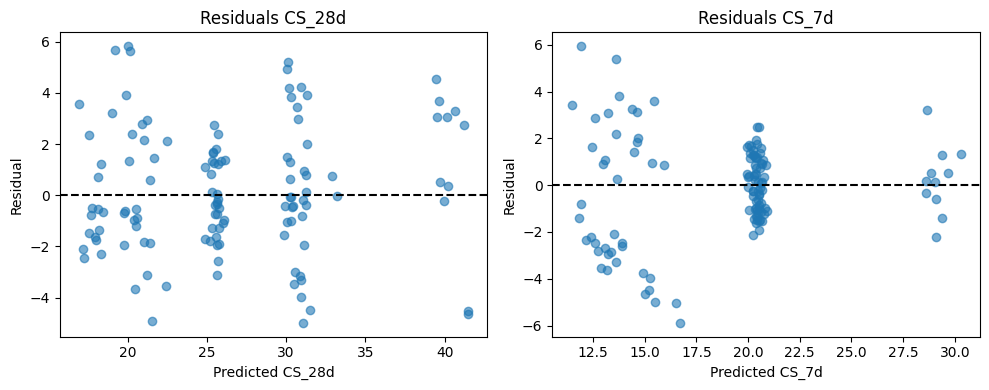

In [43]:
# 12) Residual plot and quick learning curve hint
# ---------------------------
y_pred_test = best_rf.predict(X_test)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_pred_test[:,1], y_test.iloc[:,1] - y_pred_test[:,1], alpha=0.6)
plt.axhline(0, color='k', ls='--')
plt.xlabel('Predicted CS_28d'); plt.ylabel('Residual'); plt.title('Residuals CS_28d')

plt.subplot(1,2,2)
plt.scatter(y_pred_test[:,0], y_test.iloc[:,0] - y_pred_test[:,0], alpha=0.6)
plt.axhline(0, color='k', ls='--')
plt.xlabel('Predicted CS_7d'); plt.ylabel('Residual'); plt.title('Residuals CS_7d')

plt.tight_layout()
plt.show()


In [44]:
# 13) Important cautions (printed)
# ---------------------------
print("\nImportant cautions:")
print("- Your CSV is synthetic-augmented; model may learn synthetic patterns and not generalize to real lab data.")
print("- If you later add real experimental data, retrain and retune (and keep a real holdout test).")
print("- If CS_7d is highly predictive of CS_28d, that is expected; if you want 'pure' predictions without early-age tests, drop CS_7d from FEATURES and retrain.")



Important cautions:
- Your CSV is synthetic-augmented; model may learn synthetic patterns and not generalize to real lab data.
- If you later add real experimental data, retrain and retune (and keep a real holdout test).
- If CS_7d is highly predictive of CS_28d, that is expected; if you want 'pure' predictions without early-age tests, drop CS_7d from FEATURES and retrain.


In [45]:
# 14) Optional improvements listed
# ---------------------------
print("\nOptional next steps: add slump/density/UPV, create derived features, use SHAP for explainability, or extract real data from PDFs for higher-fidelity training.")



Optional next steps: add slump/density/UPV, create derived features, use SHAP for explainability, or extract real data from PDFs for higher-fidelity training.


In [47]:
# 15) End
# ---------------------------
print("\nScript finished. Models and outputs are saved.")


Script finished. Models and outputs are saved.
